<a href="https://colab.research.google.com/github/aiyman14/DACSS-758-Text-as-Data/blob/main/Week5LabPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing with Gensim

In [5]:
# install gensim
!pip install gensim

In [6]:
from gensim.parsing.preprocessing import STOPWORDS, remove_stopwords
from gensim.parsing.preprocessing import strip_punctuation
from gensim.parsing.preprocessing import stem_text
from gensim.parsing.preprocessing import strip_multiple_whitespaces
from gensim.parsing.preprocessing import strip_numeric, strip_short
from gensim.parsing.preprocessing import preprocess_string, strip_tags
from gensim.models.phrases import Phrases

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [8]:
# read in txt file (uploaded directly to Colab)
text_file = open("/content/prideprejudice (1).txt", "r", encoding="utf-8")
prideprej = text_file.readlines()
text_file.close()

In [9]:
prideprej[0:25]

['PRIDE AND PREJUDICE\n',
 '\n',
 'By Jane Austen\n',
 '\n',
 '\n',
 '\n',
 'Chapter 1\n',
 '\n',
 '\n',
 'It is a truth universally acknowledged, that a single man in possession\n',
 'of a good fortune, must be in want of a wife.\n',
 '\n',
 'However little known the feelings or views of such a man may be on his\n',
 'first entering a neighbourhood, this truth is so well fixed in the minds\n',
 'of the surrounding families, that he is considered the rightful property\n',
 'of some one or other of their daughters.\n',
 '\n',
 '"My dear Mr. Bennet," said his lady to him one day, "have you heard that\n',
 'Netherfield Park is let at last?"\n',
 '\n',
 'Mr. Bennet replied that he had not.\n',
 '\n',
 '"But it is," returned she; "for Mrs. Long has just been here, and she\n',
 'told me all about it."\n',
 '\n']

In [10]:
# word count before preprocessing
wc = [len(item.split()) for item in prideprej]
sum(wc)

121567

In [11]:
# lowercase
print(prideprej[29])
prideprej_lower = [item.lower() for item in prideprej]
print(prideprej_lower[29])

"_You_ want to tell me, and I have no objection to hearing it."

"_you_ want to tell me, and i have no objection to hearing it."



In [12]:
# punctuation
print(prideprej_lower[29])
prideprej_clean = [strip_punctuation(item) for item in prideprej_lower]
print(prideprej_clean[29])

"_you_ want to tell me, and i have no objection to hearing it."

 you  want to tell me  and i have no objection to hearing it 



In [13]:
# white space
print(prideprej_clean[29])
prideprej_clean = [strip_multiple_whitespaces(item) for item in prideprej_clean]
print(prideprej_clean[29])

 you  want to tell me  and i have no objection to hearing it 

 you want to tell me and i have no objection to hearing it 


In [14]:
print(STOPWORDS)  # only English is available in gensim

frozenset({'once', 'every', 'hereby', 'unless', 'using', 'thru', 'mine', 'we', 'whether', 'to', 'something', 'latterly', 'how', 'ours', 'serious', 'a', 'twelve', 'go', 'anything', 'nevertheless', 'another', 'until', 'whereupon', 'should', 'say', 'after', 'everything', 'not', 'yourself', 'several', 'whom', 'meanwhile', 'upon', 'while', 'any', 'over', 'her', 'well', 'top', 'co', 'very', 'you', 'onto', 'can', 'really', 'find', 'herein', 'indeed', 'such', 'them', 'thin', 'interest', 'never', 'become', 'those', 'detail', 'only', 'seem', 'us', 'system', 'besides', 'make', 'twenty', 'except', 'anyway', 'thereupon', 'at', 'whereafter', 'if', 'might', 'full', 'ten', 'third', 'what', 'under', 'afterwards', 'hers', 'seems', 'mill', 'from', 'ever', 'formerly', 'moreover', 'may', 'within', 'sincere', 'too', 'him', 'have', 'con', 'but', 'due', 'cant', 'less', 'bill', 'anyhow', 'hasnt', 'please', 'just', 'whenever', 'amoungst', 'thick', 'amount', 'into', 'get', 'most', 'his', 'yet', 'when', 'still', 

In [15]:
# stopwords
print(prideprej_clean[29])
prideprej_clean = [remove_stopwords(item) for item in prideprej_clean]
print(prideprej_clean[29])

 you want to tell me and i have no objection to hearing it 
want tell objection hearing


In [16]:
# stem (Porter)
print(prideprej_clean[29])
prideprej_clean_stemmed = [stem_text(item) for item in prideprej_clean]
print(prideprej_clean_stemmed[29])

want tell objection hearing
want tell object hear


In [17]:
# tokenize
prideprej_toks = [item.split() for item in prideprej_clean]
prideprej_toks[0:20]

[['pride', 'prejudice'],
 [],
 ['jane', 'austen'],
 [],
 [],
 [],
 ['chapter', '1'],
 [],
 [],
 ['truth', 'universally', 'acknowledged', 'single', 'man', 'possession'],
 ['good', 'fortune', 'want', 'wife'],
 [],
 ['little', 'known', 'feelings', 'views', 'man'],
 ['entering', 'neighbourhood', 'truth', 'fixed', 'minds'],
 ['surrounding', 'families', 'considered', 'rightful', 'property'],
 ['daughters'],
 [],
 ['dear', 'mr', 'bennet', 'said', 'lady', 'day', 'heard'],
 ['netherfield', 'park', 'let'],
 []]

In [18]:
# word count after preprocessing
wc = [len(item) for item in prideprej_toks]
sum(wc)

46472

In [19]:
# all at once!
prideprej_lower = [item.lower() for item in prideprej]
CUSTOM_FILTERS = [strip_punctuation, strip_multiple_whitespaces, remove_stopwords]
prideprej_toks2 = [preprocess_string(item, CUSTOM_FILTERS) for item in prideprej_lower]
prideprej_toks2[0:20]

[['pride', 'prejudice'],
 [],
 ['jane', 'austen'],
 [],
 [],
 [],
 ['chapter', '1'],
 [],
 [],
 ['truth', 'universally', 'acknowledged', 'single', 'man', 'possession'],
 ['good', 'fortune', 'want', 'wife'],
 [],
 ['little', 'known', 'feelings', 'views', 'man'],
 ['entering', 'neighbourhood', 'truth', 'fixed', 'minds'],
 ['surrounding', 'families', 'considered', 'rightful', 'property'],
 ['daughters'],
 [],
 ['dear', 'mr', 'bennet', 'said', 'lady', 'day', 'heard'],
 ['netherfield', 'park', 'let'],
 []]

In [20]:
# same word count
wc = [len(item) for item in prideprej_toks2]
sum(wc)

46472

In [21]:
# prep for wordcloud
separator = ' '
prideprej_long = [separator.join(item) for item in prideprej_toks]
print(prideprej_long)
prideprej_long = separator.join(prideprej_long)
print(prideprej_long)

['pride prejudice', '', 'jane austen', '', '', '', 'chapter 1', '', '', 'truth universally acknowledged single man possession', 'good fortune want wife', '', 'little known feelings views man', 'entering neighbourhood truth fixed minds', 'surrounding families considered rightful property', 'daughters', '', 'dear mr bennet said lady day heard', 'netherfield park let', '', 'mr bennet replied', '', 'returned mrs long', 'told', '', 'mr bennet answer', '', 'want know taken cried wife impatiently', '', 'want tell objection hearing', '', 'invitation', '', 'dear know mrs long says netherfield taken', 'young man large fortune north england came', 'monday chaise place', 'delighted agreed mr morris immediately', 'possession michaelmas servants', 'house end week', '', '', '', 'bingley', '', 'married single', '', 'oh single dear sure single man large fortune', 'thousand year fine thing girls', '', 'affect', '', 'dear mr bennet replied wife tiresome', 'know thinking marrying', '', 'design settling', 

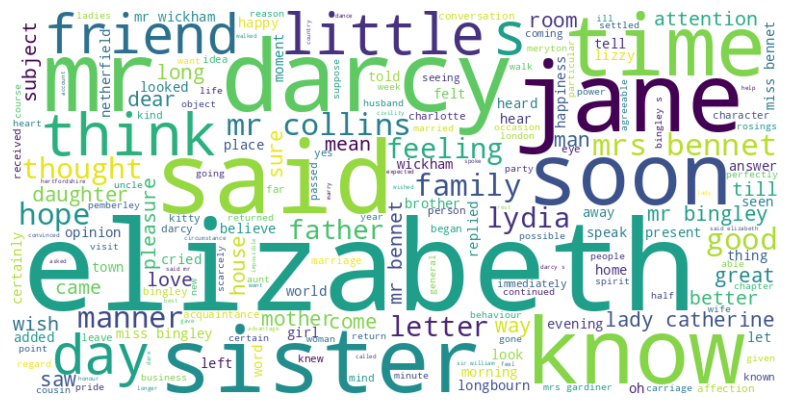

In [22]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200, random_state=2026).generate(prideprej_long)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [23]:
# remove single character strings like s
prideprej_clean = [strip_short(item, minsize=2) for item in prideprej_clean]
# re-tokenize
prideprej_toks = [item.split() for item in prideprej_clean]

In [24]:
# bigrams with phraser model
prideprej_bigrams = Phrases(prideprej_toks, min_count = 3, threshold = 10)
print(prideprej_bigrams[prideprej_toks[185]])
print(prideprej_bigrams[prideprej_toks[280]])

['mary', 'young_lady', 'deep', 'reflection', 'know', 'read']
['looked', 'gentleman', 'friend', 'mr_darcy', 'soon', 'drew', 'attention']


In [25]:
# prep for wordcloud
separator = ' '
prideprej_long = [separator.join(item) for item in prideprej_bigrams[prideprej_toks]]
prideprej_long = separator.join(prideprej_long)

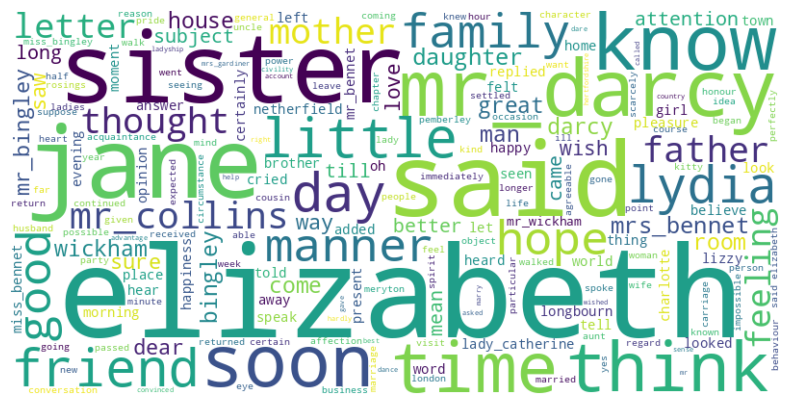

In [26]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200, random_state=2026).generate(prideprej_long)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [27]:
from gensim.parsing.preprocessing import STOPWORDS
print(len(STOPWORDS))

337
